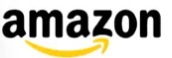
# Amazon Sales Analysis

* Analyzed **10,000 Amazon sales records** to understand sales performance and customer behavior.
* Explored **sales trends, customer demographics, product demand, category revenue, payment methods, and correlations**.
* Used **Python, Pandas, Matplotlib, and Seaborn** for data analysis and visualization.
* Converted the findings into **business insights and recommendations**.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv('amazon_sales_data.csv')
df.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,payment_method,gender,age,total_sales
0,A10000,12-11-2026,29-03-2026,23-02-2026,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42468,Card,Female,43,127403
1,A10001,03-12-2026,18-01-2026,03-05-2026,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36139,COD,Male,47,72278
2,A10002,07-06-2026,24-10-2026,24-10-2026,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47149,UPI,Male,36,188596
3,A10003,27-05-2026,08-01-2026,27-02-2026,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18488,Card,Female,49,18488
4,A10004,03-11-2026,13-10-2026,22-07-2026,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742,UPI,Male,55,1742


In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df = df.rename(columns={'total_sales=': 'total_sales'})

In [55]:
print(df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

(10000, 21)
Number of Rows: 10000
Number of Columns: 21


In [56]:
print(df.dtypes)

order_id            str
order_date          str
ship_date           str
delivery_date       str
order_status        str
customer_id         str
customer_name       str
country             str
state               str
city                str
product_id          str
product_name        str
category            str
sub_category        str
brand               str
quantity          int64
unit_price        int64
payment_method      str
gender              str
age               int64
total_sales       int64
dtype: object


In [57]:
print(df.isnull().sum())

order_id          0
order_date        0
ship_date         0
delivery_date     0
order_status      0
customer_id       0
customer_name     0
country           0
state             0
city              0
product_id        0
product_name      0
category          0
sub_category      0
brand             0
quantity          0
unit_price        0
payment_method    0
gender            0
age               0
total_sales       0
dtype: int64


In [58]:
numerical_columns = df.select_dtypes(include="number").columns

print(df[numerical_columns].mean())

quantity           3.0144
unit_price     25126.5201
age               41.5448
total_sales    75421.4684
dtype: float64


In [59]:
numerical_columns = df.select_dtypes(include="number").columns

print(df[numerical_columns].median())

quantity           3.0
unit_price     24880.5
age               41.0
total_sales    59761.5
dtype: float64


In [60]:
numerical_columns = df.select_dtypes(include="number").columns

print(df[numerical_columns].mode().iloc[0])

quantity           5.0
unit_price     37409.0
age               25.0
total_sales    21530.0
Name: 0, dtype: float64


In [61]:
numerical_columns = df.select_dtypes(include="number").columns

print(df[numerical_columns].std())

quantity           1.420350
unit_price     14343.924352
age               13.927117
total_sales    59157.870991
dtype: float64


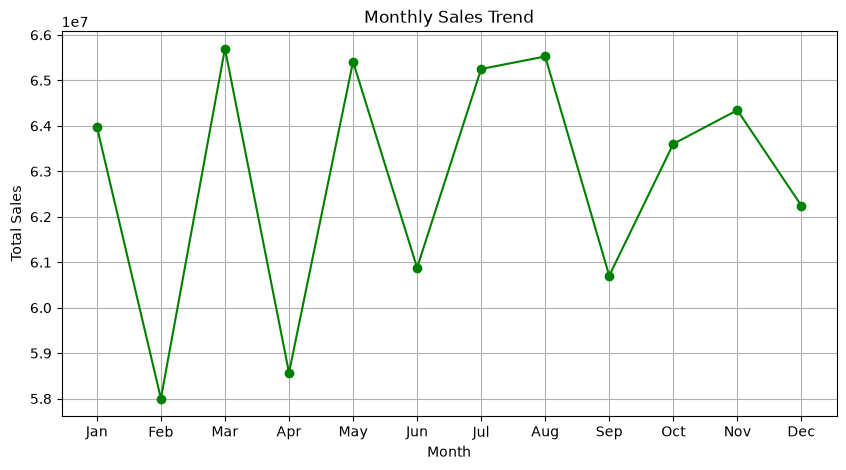

In [62]:
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True, errors="coerce")

df["month"] = df["order_date"].dt.month

monthly_sales = df.groupby("month")["total_sales"].sum()

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values,
         marker="o", color="green")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13), months)

plt.grid(True)
plt.show()

# Chart 1 — Monthly Sales Trend
— What is the monthly sales performance?

**Observation**

- March records the highest monthly sales at approximately ₹65.70M.
- August and May also show relatively strong sales performance at approximately ₹65.53M and ₹65.41M.
- February records the lowest monthly sales at approximately ₹58.00M.
- The difference between the highest and lowest months is approximately ₹7.70M.
- Overall, sales remain relatively consistent across the months, with moderate fluctuations.

**Analysis**

The monthly sales trend indicates a relatively stable sales pattern throughout the year. However, certain months perform better than others.

March, August, and May represent stronger sales periods, while February shows comparatively lower performance. This variation can be useful for planning promotional campaigns, inventory levels, and marketing activities.

**Business Recommendation**

- Plan promotional campaigns before weaker sales periods such as February.
- Ensure adequate inventory and marketing support during stronger months.
- Compare promotions, product availability, and customer activity across months to identify the factors behind the sales variation.

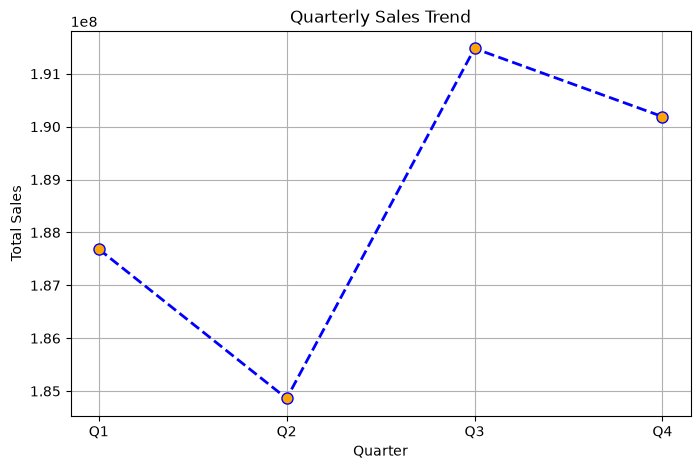

In [63]:
# Convert order_date into date format
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True, errors="coerce")

# Get quarter
df["quarter"] = df["order_date"].dt.quarter

# Calculate quarterly sales
quarterly_sales = df.groupby("quarter")["total_sales"].sum()

# Plot
plt.figure(figsize=(8, 5))

plt.plot(quarterly_sales.index, quarterly_sales.values,
         marker="o", color="blue" , linewidth=2, markersize=8 , markerfacecolor="orange" , linestyle="--")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks([1, 2, 3, 4], ["Q1", "Q2", "Q3", "Q4"])

plt.grid(True)
plt.show()

# Chart 2 — Quarterly Sales Trend
— How does sales performance vary across quarters?

**Observation**
- Q3 records the highest quarterly sales at approximately ₹191.48M.
- Q4 follows closely with approximately ₹190.19M.
- Q1 records approximately ₹187.68M.
- Q2 records the lowest quarterly sales at approximately ₹184.86M.
- The difference between the highest and lowest quarters is approximately ₹6.62M.
- Sales are relatively evenly distributed across all four quarters.

**Analysis**

The quarterly sales trend shows that the business does not depend heavily on one particular quarter. Q3 and Q4 perform slightly better, while Q2 records the lowest sales.

The relatively small difference between the quarters indicates a fairly stable sales pattern across the year.

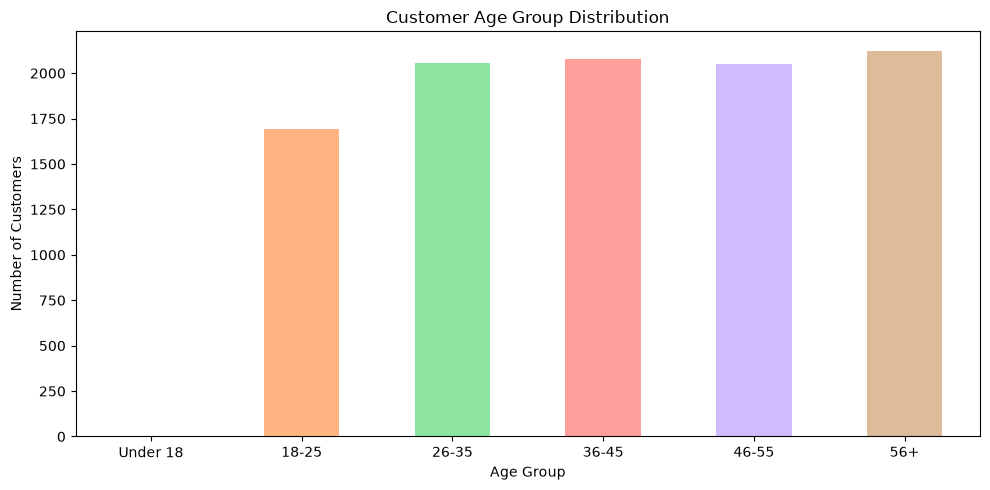

In [64]:
# Create age groups
age_bins = [0, 17, 25, 35, 45, 55, 100]

age_labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

# Count customers/orders in each age group
age_group_counts = (
    df["age_group"]
    .value_counts()
    .reindex(age_labels, fill_value=0)
)

# Create bar chart
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind="bar" , color=sns.color_palette("pastel"))

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# chart 3 — Customer Age Group
— How are customers distributed across age groups?

**Observation**
- The 56+ age group has the highest representation with 2,124 records.
- The 36–45 group follows with 2,076 records.
- The 26–35 and 46–55 groups contain 2,058 and 2,048 records, respectively.
- The 18–25 group has the lowest representation with 1,694 records.
- There are no records for customers below 18 in the dataset.

**Analysis** 

The customer base is spread across the adult age groups, with the 56+ segment having the largest representation.

The 18–25 segment has comparatively fewer records, which may indicate an opportunity to investigate whether younger customers have different product preferences or purchasing behaviour.

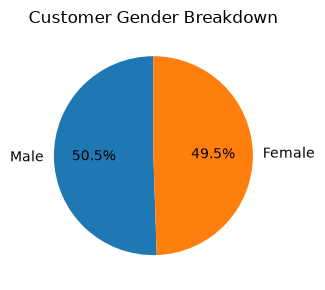

In [65]:
# Count customers by gender
gender_counts = df["gender"].value_counts()

# Create pie chart
plt.figure(figsize=(4, 3))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Gender Breakdown")

plt.tight_layout()
plt.show()

# Chart 4 — Customer Gender Distribution
— How is the customer base distributed by gender?

**Observation**
- Male customers account for 5,053 records, approximately 50.5%.
- Female customers account for 4,947 records, approximately 49.5%.
- The difference between the two groups is only 106 records.
- The chart therefore shows an almost evenly balanced gender distribution.

**Analysis** 

The customer base is highly balanced by gender. Neither group represents a substantially larger share of the dataset.

However, customer count alone does not indicate differences in purchasing behaviour. Product preferences, average order value, and category performance would provide additional insight.

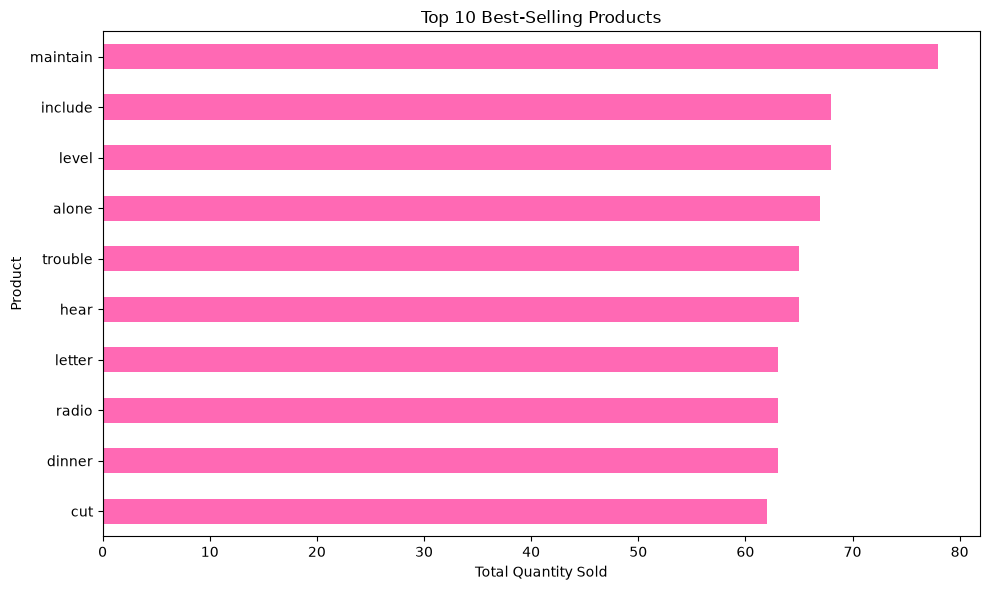

In [66]:
# Calculate total quantity sold for each product
top_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh" , color="#FF69B4")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

# Chart 5 — Top Products by Quantity
— Which products have the highest sales quantity?

**Observation**
- "maintain" has the highest quantity at 78 units.
- "level" and "include" follow with 68 units each.
- The other products in the top group have quantities in a relatively similar range.
- No single product overwhelmingly dominates the chart.

**Analysis**

The chart shows that demand is distributed across several leading products rather than being concentrated in one product.

The products appearing at the top of the chart can therefore be considered useful candidates for inventory monitoring, promotions,bundling, and cross-selling.

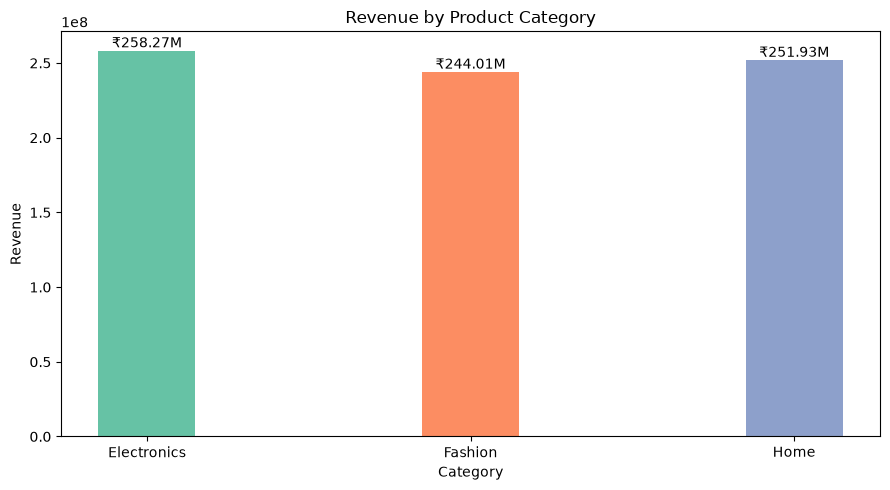

In [67]:
category_revenue = df.groupby("category")["total_sales"].sum()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values,
    color=sns.color_palette("Set2"),
    width=0.3
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

# Show exact revenue on each bar
for bar, value in zip(bars, category_revenue.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"₹{value/1000000:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Chart 6 — Revenue by Category
— Which product category generates the highest revenue?

**Observation**
- Electronics generates the highest revenue at approximately ₹258.27M.
- Home follows with approximately ₹251.93M.
- Fashion records approximately ₹244.01M.
- Electronics exceeds Fashion by approximately ₹14.26M.
- Electronics exceeds Home by approximately ₹6.34M.
- All three categories contribute substantially to total revenue.

**Analysis**

Electronics is the largest revenue-generating category, followed by Home and Fashion.

Although Electronics leads, the differences between the categories are not extremely large. This indicates that Home and Fashion remain important contributors to overall business revenue.

**Business Recommendation**
- Prioritize inventory availability for the Electronics category.
- Identify high-performing Electronics products for   cross-selling and bundling opportunities.
- Continue monitoring Home and Fashion because both contribute   significantly to overall revenue.

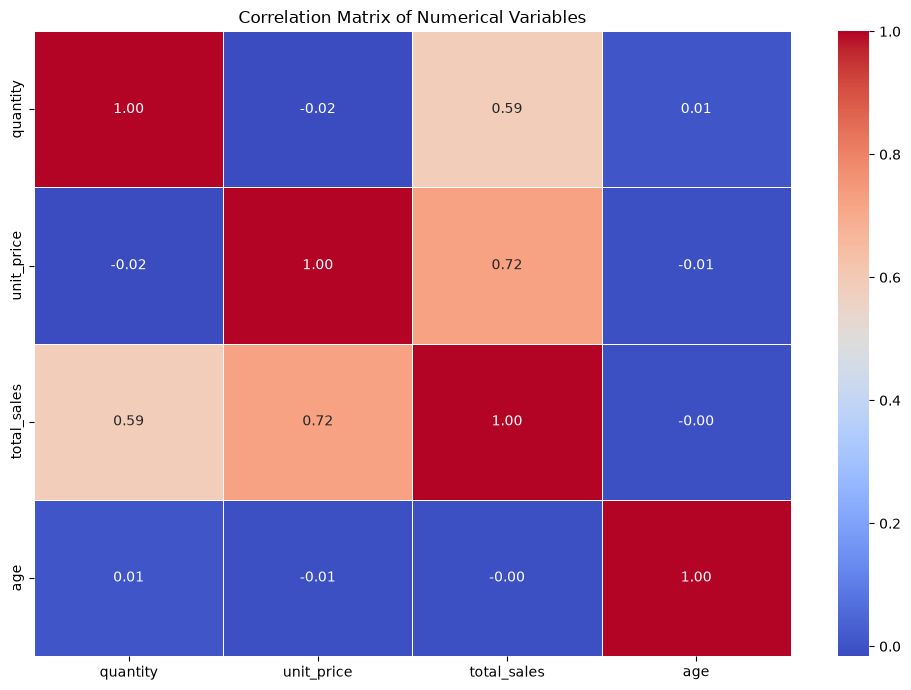

In [68]:
# Select numerical columns
numerical_columns = [
    "quantity",
    "unit_price",
    "total_sales",
    "age"
]

# Calculate correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Chart 7 — Correlation Analysis
— What relationships exist between the numerical variables?

**Observation**
- Unit price and total sales show a relatively strong positive correlation of approximately 0.72.
- Quantity and total sales show a moderate positive correlation of approximately 0.59.
- Age and total sales have almost no correlation, approximately −0.005.
- Quantity and unit price also show almost no correlation, approximately −0.016.

**Analysis**

The correlation chart indicates that unit price has the strongest positive relationship with total sales among the variables analysed.

Quantity also has a positive relationship with total sales, while age has almost no linear relationship with total sales.

These results represent association, not causation. For example, the positive correlation between unit price and total sales does not by itself mean that increasing prices will cause sales to increase.

**Business Recommendation**
- Identify higher-value products that combine strong unit prices with strong sales performance.
- Analyse quantity and unit-price combinations to identify opportunities for premium products and bundles.
- Do not use customer age as the sole predictor of sales value.
- Combine correlation analysis with product, category, and customer-level analysis before making pricing decisions.

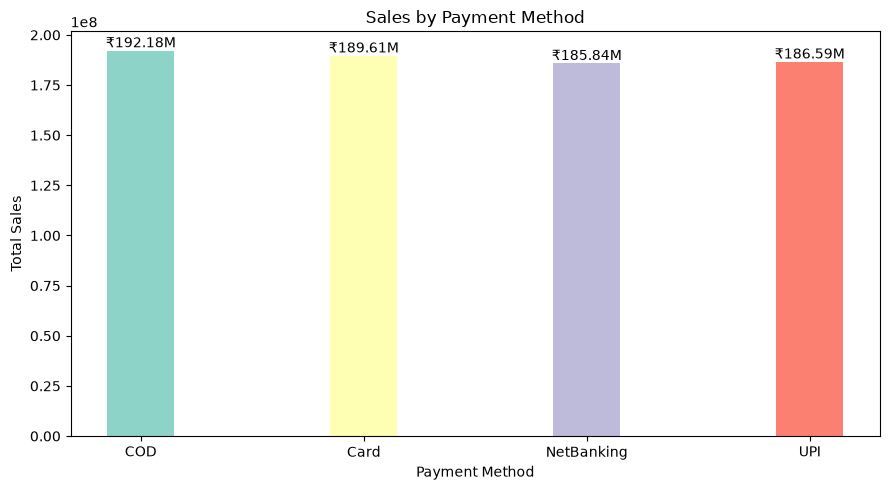

In [69]:
# Sales by Payment Method

payment_sales = df.groupby("payment_method")["total_sales"].sum()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    payment_sales.index,
    payment_sales.values,
    color = sns.color_palette("Set3"),
    width=0.3
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")

# Show exact sales value
for bar, value in zip(bars, payment_sales.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"₹{value/1000000:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Chart 8 — Sales by Payment Method
— How does sales performance vary by payment method?

**Observation**

- COD records the highest sales at approximately ₹192.18M.
- Card follows with approximately ₹189.61M.
- UPI records approximately ₹186.59M.
- NetBanking records approximately ₹185.84M.
- The difference between the highest and lowest payment methods is approximately ₹6.34M.
- Overall, sales are relatively evenly distributed across the four payment methods.

**Analysis** 

The payment-method analysis shows that no single payment method overwhelmingly dominates sales.

COD records the highest sales, while NetBanking records the lowest, but the difference between them is relatively small. This indicates that customers use multiple payment methods.

# Conclusion

* Sales remained **relatively stable** across months and quarters.
* **Electronics** generated the highest revenue among the categories.
* The customer base was **almost evenly split by gender**.
* `unit_price` had the strongest positive correlation with `total_sales`.
* Sales were **fairly distributed across payment methods**.
* The findings can support **marketing, inventory, customer segmentation, and sales planning**.

